# Informe de Selección de Modelo — Áreas cultivadas y producción agrícola en Antioquia (2024)

- **Grupo**: Carolina Florez Lopez — 1007471846
Juan Camilo Ramirez Chaverra — 1035236314
Monica Patricia Vega Arrieta — 1068136312
- **Variante**: regresión
- **Dataset**: Áreas cultivadas y producción agrícola en Antioquia desde 1990-2025 (Datos Abiertos Colombia), <https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Areas-cultivadas-y-produccion-agr-cola-en-Antioqui/t2ca-uae5>
- **Fecha**: [2026-09-30]

## 0. Configuración

La celda siguiente importa todas las librerías que usa el notebook y fija la semilla aleatoria. Si corre sin error, el entorno está listo:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

## 1. Los datos

### 1.1 Carga del archivo original

La celda siguiente lee el archivo original y muestra su tamaño. Los números vienen con coma decimal (`1700,00`), por eso se lee con `decimal=","`:

In [ ]:
DATA_PATH = "Areas_cultivadas_y_produccion_agrícola_en_Antioquia_desde_1990-2025_20260928.csv"

raw = pd.read_csv(DATA_PATH, decimal=",")
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")

37,882 rows x 8 columns


El archivo tiene 37,882 filas y 8 columnas. **Una fila es un rubro (cultivo) en un municipio de Antioquia en un año**, con su área total, su área en producción y su volumen de producción. La celda siguiente muestra las primeras filas:

In [ ]:
raw.head()

,Tipo,Rubro,Subregion,Año,Municipio,Área Total,Área Producción,Volumen Producción
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


Hay seis columnas de contexto (tipo de cultivo, rubro, subregión, año, municipio) y tres cifras numéricas. La celda siguiente lista, para cada columna, su tipo, sus faltantes y sus valores distintos:

In [ ]:
column_summary = pd.DataFrame(
    {
        "type": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "distinct values": raw.nunique(),
    }
)
column_summary

,type,missing,distinct values
Tipo,str,0,3
Rubro,str,0,159
Subregion,str,0,9
Año,int64,0,36
Municipio,str,0,151
Área Total,float64,48,4601
Área Producción,float64,509,4479
Volumen Producción,float64,231,10012


Solo las tres columnas numéricas tienen faltantes: 48 en `Área Total`, 509 en `Área Producción` y 231 en `Volumen Producción`. El archivo cubre 36 años (1990 a 2025), 151 municipios y 159 rubros.

### 1.2 Arreglos estructurales

Antes de dividir los datos solo se hacen arreglos que **no calculan nada a partir de otras filas**. La celda
siguiente hace lo siguiente, en este orden:

1. Renombra las columnas sin tildes ni espacios.
2. Elimina las filas repetidas para un mismo (año, rubro, municipio): no se sabe cuál es la correcta.
3. Elimina las filas donde el rendimiento no se puede calcular (área en producción, volumen o área total en
   cero o negativos, o faltantes). El objetivo no se imputa.
4. Crea el objetivo `Rendimiento` = volumen ÷ área en producción (toneladas por hectárea).
5. Crea tres columnas derivadas del mismo archivo: `RendPrev` y `AreaTotalPrev` (el rendimiento y el área total
   del **año anterior** para el mismo rubro y municipio, copiados tal cual) y `PropProd` (área en producción
   ÷ área total de la misma fila).
6. Conserva solo el año 2024 y elimina `Anio` (constante) y `Volumen` (fuga: es el numerador del objetivo).

In [ ]:
TARGET = "Rendimiento"
YEAR = 2024
KEY = ["Anio", "Rubro", "Municipio"]
LEAKING_COLS = ["Volumen"]
CONSTANT_COLS = ["Anio"]

data = raw.rename(
    columns={
        "Año": "Anio",
        "Área Total": "AreaTotal",
        "Área Producción": "AreaProd",
        "Volumen Producción": "Volumen",
    }
)

n_before = len(data)
data = data.drop_duplicates(KEY, keep=False)
n_duplicates_removed = n_before - len(data)
n_year_rows = int((data["Anio"] == YEAR).sum())

defined = (data["AreaProd"] > 0) & (data["Volumen"] > 0) & (data["AreaTotal"] > 0)
data = data[defined].copy()
data[TARGET] = data["Volumen"] / data["AreaProd"]

previous = data[KEY + [TARGET, "AreaTotal"]].copy()
previous["Anio"] += 1
previous = previous.rename(columns={TARGET: "RendPrev", "AreaTotal": "AreaTotalPrev"})
data = data.merge(previous, on=KEY, how="left", validate="one_to_one")
data["PropProd"] = data["AreaProd"] / data["AreaTotal"]

data = data[data["Anio"] == YEAR].drop(columns=LEAKING_COLS + CONSTANT_COLS).reset_index(drop=True)

print(f"duplicated rows removed (whole file): {n_duplicates_removed:,}")
print(f"{YEAR} rows before / after removing undefined yields: {n_year_rows:,} / {len(data):,}")
print(f"{data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"missing values left: {data.isna().sum().sum()}")
data.isna().sum()[lambda counts: counts > 0]

duplicated rows removed (whole file): 147
2024 rows before / after removing undefined yields: 1,712 / 1,662
1,662 rows x 10 columns
missing values left: 480


RendPrev         240
AreaTotalPrev    240
dtype: int64

Tras los arreglos quedan 1,662 filas y 10 columnas: 9 predictoras y el objetivo. Se
eliminaron 147 filas repetidas en todo el archivo y, para 2024, 50 filas con rendimiento
indefinido. Quedan 480 valores faltantes, todos en `RendPrev` (240) y
`AreaTotalPrev` (240): son los rubros que en 2024 aparecen en un municipio pero no tenían registro
en 2023. El pipeline de la Sección 4 los rellena.

Ninguno de estos pasos aprende nada de otras filas: `RendPrev` y `AreaTotalPrev` copian un dato observado del
año anterior y no usan ningún valor de 2024 de otra fila, así que no filtran información del conjunto de prueba.



### 1.3 El objetivo

La celda siguiente describe el objetivo (toneladas por hectárea) y las columnas de área, para ver su escala y su asimetría:

In [ ]:
display(data[TARGET].describe().round(2))
data[["AreaTotal", "AreaProd", "AreaTotalPrev", "RendPrev", "PropProd"]].describe().round(2)

count    1662.00
mean       11.59
std        18.48
min         0.20
25%         2.00
50%         6.00
75%        14.00
max       260.00
Name: Rendimiento, dtype: float64

,AreaTotal,AreaProd,AreaTotalPrev,RendPrev,PropProd
count,1662.00,1662.00,1422.00,1422.00,1662.00
mean,266.88,239.27,281.66,11.87,0.89
std,886.81,818.50,893.96,19.09,0.19
min,0.06,0.03,0.15,0.20,0.07
25%,8.00,6.22,10.00,1.90,0.83
50%,30.20,25.00,35.75,6.00,0.97
75%,150.00,132.23,174.88,14.00,1.00
max,11140.00,11040.00,11040.00,180.00,2.50


El rendimiento va de 0.2 a 260.0 t/ha, con mediana 6.0 y media 11.59: la media queda por encima de la mediana porque unos pocos rubros de rendimiento muy alto la jalan. Las áreas también son muy asimétricas: `AreaTotal` tiene mediana 30.2 ha y máximo 11,140 ha.

### 1.4 Verificación de requisitos mínimos

La celda siguiente verifica cada requisito mínimo y muestra `PASS` o `FAIL`. Es la evidencia del Entregable 1:

In [ ]:
predictors = data.drop(columns=TARGET)
n_numeric = predictors.select_dtypes(include="number").shape[1]
n_categorical = predictors.shape[1] - n_numeric
n_target_values = data[TARGET].nunique()
n_missing = int(predictors.isna().sum().sum())

requirements = {
    f"numeric target with >= 50 distinct values (it has {n_target_values})": (
        pd.api.types.is_numeric_dtype(data[TARGET]) and n_target_values >= 50
    ),
    f"at least 1,000 rows (it has {len(data):,})": len(data) >= 1000,
    f"at least 8 predictors (it has {predictors.shape[1]})": predictors.shape[1] >= 8,
    f"numeric and categorical columns ({n_numeric} and {n_categorical})": n_numeric > 0 and n_categorical > 0,
    f"a preprocessing need ({n_missing} missing, {n_categorical} to encode)": n_missing > 0 or n_categorical > 0,
}

for requirement, passed in requirements.items():
    print(f"{'PASS' if passed else 'FAIL'}  {requirement}")

PASS  numeric target with >= 50 distinct values (it has 388)
PASS  at least 1,000 rows (it has 1,662)
PASS  at least 8 predictors (it has 9)
PASS  numeric and categorical columns (5 and 4)
PASS  a preprocessing need (480 missing, 4 to encode)


Todas las líneas pasan.

**Entregable 1 de 8 — Ficha del dataset**

- **Nombre y fuente** (con enlace): *Áreas cultivadas y producción agrícola en Antioquia desde 1990-2025*,
  Datos Abiertos Colombia (datos.gov.co), https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Areas-cultivadas-y-produccion-agr-cola-en-Antioqui/t2ca-uae5. Archivo descargado el 2026-09-28.
- **Qué representa una fila**: un rubro (cultivo) en un municipio de Antioquia en un año, con su área total,
  su área en producción y su volumen de producción.
- **Tamaño tras los arreglos estructurales** (filas × columnas): 1,662 × 10 (9 predictoras
  y el objetivo), solo del año 2024.
- **El objetivo**: `Rendimiento`, en toneladas por hectárea (volumen ÷ área en producción; asumimos las unidades
  estándar de las evaluaciones agrícolas: toneladas y hectáreas). Va de 0.2 a 260.0, con mediana
  6.0.
- **La decisión que un modelo podría apoyar**: estimar el rendimiento esperado de un rubro en un municipio
  para contrastarlo con el rendimiento reportado y priorizar la revisión de los reportes más atípicos.
  Lo usaría el equipo que consolida las estadísticas agrícolas.
- **Columnas eliminadas antes de modelar**: `Volumen` (fuga: es el numerador del objetivo, y es justamente la
  cifra que se quiere contrastar) y `Anio` (constante: con un solo año no aporta información). El archivo no
  tiene columna identificadora.
- **Arreglos estructurales antes de la división**: nombres de columna sin tildes; 147 filas repetidas
  eliminadas; filas con rendimiento indefinido eliminadas (el objetivo no se imputa); creación de `PropProd`
  (aritmética de la misma fila) y de `RendPrev` y `AreaTotalPrev` (dato observado del año anterior copiado desde
  otra fila). Ninguno estima nada a partir de los datos.
- **Aviso sobre las columnas derivadas**: el archivo original solo tiene 8 columnas, de las cuales 6 sirven como
  predictoras en un solo año (se excluyen `Volumen`, que filtra el objetivo, y `Anio`, que es constante). Las tres columnas derivadas son las que permiten llegar a 9 predictoras,
  y además aportan información útil (el historial del propio rubro en el municipio).

## 2. La métrica

### Por qué RMSE

**RMSE** (raíz del error cuadrático medio) se expresa en la unidad del objetivo, aquí toneladas por hectárea,
así que se lee directamente como el tamaño típico del error al estimar un rendimiento. Además, cuenta más los
errores grandes que los pequeños. Menor es mejor.



La celda siguiente guarda el nombre de la métrica en una sola constante. Todos los pasos posteriores la usan:

In [ ]:
SCORING = "neg_root_mean_squared_error"

**Entregable 2 de 8 — La métrica**

- **La métrica**: RMSE en toneladas por hectárea, usado en el torneo, en el ajuste de hiperparámetros y en la
  prueba final.
- **Su unidad, y qué significaría un error del tamaño del valor típico del objetivo**: toneladas por hectárea.
  El rendimiento mediano es 6.0 t/ha; un RMSE de ese tamaño significaría que el modelo se equivoca, en
  promedio, tanto como vale el rendimiento típico, es decir, que no aporta nada.
- **Por qué los errores grandes deben contar más**: si el modelo estima 5 t/ha para un rubro que reportó 60,
  ese reporte se revisa (o se deja pasar) por una diferencia enorme; pocos errores muy grandes hacen más daño a
  un control de calidad que muchos errores pequeños.

## 3. División de los datos

### 3.1 El conjunto de prueba

La celda siguiente separa las predictoras del objetivo y aparta el 20 % de las filas como conjunto de prueba:

In [ ]:
X = data.drop(columns=TARGET)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

La celda siguiente revisa el tamaño de cada parte y su rendimiento medio y mediano:

In [ ]:
pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "mean yield": [y_train.mean(), y_test.mean()],
        "median yield": [y_train.median(), y_test.median()],
    },
    index=["training set", "test set"],
).round(2)

,rows,mean yield,median yield
training set,1329,11.57,6.5
test set,333,11.66,6.0


El conjunto de entrenamiento tiene 1,329 filas y el de prueba 333, con rendimientos medios cercanos (11.57 y 11.66 t/ha).
**Desde aquí hasta la Sección 7, `X_test` y `y_test` no se usan.**

### 3.2 Los pliegues de validación cruzada

> **En `scikit-learn`.** `KFold` define los pliegues. `shuffle=True` mezcla las filas antes de dividirlas, para
> que ningún orden del archivo decida los pliegues; como usa aleatoriedad, recibe la semilla. El objeto se pasa
> como `cv=` a toda función de validación cruzada.

La celda siguiente crea el objeto de pliegues, una sola vez. Se pasa a todos los pasos de validación cruzada de
las Secciones 5 y 6:

In [ ]:
N_FOLDS = 5
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

La celda siguiente lista los cinco pliegues, con las filas de ajuste, el tamaño del pliegue de validación y su rendimiento medio:

In [ ]:
fold_rows = []
for fold, (fit_index, validation_index) in enumerate(cv.split(X_train, y_train), start=1):
    fold_rows.append(
        {
            "fold": fold,
            "rows fitted on": len(fit_index),
            "validation rows": len(validation_index),
            "validation mean yield": y_train.iloc[validation_index].mean(),
        }
    )

pd.DataFrame(fold_rows).set_index("fold").round(2)

,rows fitted on,validation rows,validation mean yield
fold,,,
1,1063,266,11.43
2,1063,266,12.19
3,1063,266,13.07
4,1063,266,10.33
5,1064,265,10.82


Cada modelo se ajusta con 1,063 o 1,064 filas y se evalúa con 265 o 266. El rendimiento medio de cada pliegue de validación va de 10.33 a 13.07 t/ha. Los cinco pliegues son los mismos para todos los modelos.

**Entregable 3 de 8 — La división**

- **Tamaños**: 1,329 filas para entrenamiento y 333 para prueba.
- **Por qué esta proporción para la prueba**: 20 % deja 333 filas, suficientes para una sola nota final,
  y conserva 1,329 para entrenar y comparar modelos; con solo 1,662 filas, una prueba más grande
  dejaría pocas para entrenar.
- **Pliegues y filas por ajuste y evaluación**: 5 pliegues. Cada modelo se ajusta con 1,063 o
  1,064 filas y se evalúa con 265 o 266.
- **Parecido del objetivo entre las partes**: rendimiento medio de 11.57 t/ha en entrenamiento y
  11.66 t/ha en prueba; los pliegues de validación van de 10.33 a 13.07 t/ha.
- **Regla para el conjunto de prueba de aquí en adelante**: `X_test` y `y_test` se usan una sola vez, en la
  Sección 7, para evaluar el modelo final.

## 4. El pipeline de preprocesamiento

### 4.1 Grupos de columnas

La celda siguiente asigna cada columna predictora a un grupo. Las numéricas se separan en dos: las que tienen una cola muy larga (áreas y rendimiento del año anterior) y la proporción `PropProd`:

In [ ]:
NUMERIC_COLS = X_train.select_dtypes(include="number").columns.tolist()
CATEGORICAL_COLS = [column for column in X_train.columns if column not in NUMERIC_COLS]

SKEWED_COLS = ["AreaTotal", "AreaProd", "AreaTotalPrev", "RendPrev"]
OTHER_NUMERIC_COLS = [column for column in NUMERIC_COLS if column not in SKEWED_COLS]

print(f"skewed numeric ({len(SKEWED_COLS)}): {SKEWED_COLS}")
print(f"other numeric ({len(OTHER_NUMERIC_COLS)}): {OTHER_NUMERIC_COLS}")
print(f"categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")

skewed numeric (4): ['AreaTotal', 'AreaProd', 'AreaTotalPrev', 'RendPrev']
other numeric (1): ['PropProd']
categorical (4): ['Tipo', 'Rubro', 'Subregion', 'Municipio']


Una columna que quede fuera de todos los grupos se **descartaría sin aviso**. La celda siguiente comprueba que cada predictora esté en exactamente un grupo, y detiene el notebook si no es así:

In [ ]:
assigned = SKEWED_COLS + OTHER_NUMERIC_COLS + CATEGORICAL_COLS

assert len(assigned) == len(set(assigned)), "a column is in more than one group"
assert set(assigned) == set(X_train.columns), "a column is in no group, or a name is misspelled"
print(f"all {len(assigned)} predictor columns are in exactly one group")

all 9 predictor columns are in exactly one group


### 4.2 El tratamiento de cada grupo

- **Numéricas asimétricas.** Se aplica `log1p`, luego se rellenan los faltantes con la **mediana** de las filas
  de ajuste y por último se **estandarizan**. El logaritmo evita que unas pocas áreas enormes dominen las
  distancias de KNN y los coeficientes de la regresión ridge.
- **Otra numérica (`PropProd`).** Mediana y estandarización.
- **Categóricas.** Los faltantes se rellenan con la categoría más frecuente y luego **one-hot encoding**
  convierte cada columna en una columna 0/1 por categoría.

> **En `scikit-learn`.** `ColumnTransformer` envía cada grupo a sus pasos y, por defecto, **descarta** toda
> columna que no esté en un grupo (`remainder="drop"`); por eso 4.1 lo verifica. `handle_unknown="ignore"`
> escribe ceros para una categoría que no vio al ajustar: un municipio o rubro poco frecuente puede faltar en
> los pliegues de ajuste de una ronda. `FunctionTransformer(np.log1p)` aplica el logaritmo sin aprender nada.

La celda siguiente construye el preprocesador con los tres grupos. Todavía no ajusta nada:

In [ ]:
skewed_steps = Pipeline(
    [
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
other_numeric_steps = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
categorical_steps = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("skewed", skewed_steps, SKEWED_COLS),
        ("other_numeric", other_numeric_steps, OTHER_NUMERIC_COLS),
        ("categorical", categorical_steps, CATEGORICAL_COLS),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

La celda siguiente define `make_model`, que une el preprocesador y un modelo en un solo pipeline. Todos los modelos de las Secciones 5, 6 y 7 se construyen con ella, así todos reciben exactamente el mismo preprocesamiento:

In [ ]:
def make_model(estimator: BaseEstimator) -> Pipeline:
    """Join the shared preprocessor and a model into one pipeline.

    Args:
        estimator: Any scikit-learn regressor, not yet fitted.

    Returns:
        A pipeline that prepares the columns and then applies the model.
    """
    return Pipeline([("prep", preprocessor), ("model", estimator)])

La celda siguiente ajusta el preprocesador con el conjunto de entrenamiento **solo para mirar su salida**: cuántas columnas recibirán los modelos y cómo se ven:

In [ ]:
X_train_preproc = preprocessor.fit_transform(X_train)

print(f"{X_train.shape[1]} columns in, {X_train_preproc.shape[1]} columns out")
print(f"distinct rubros: {X_train['Rubro'].nunique()}, distinct municipios: {X_train['Municipio'].nunique()}")
X_train_preproc.head(3)

9 columns in, 254 columns out
distinct rubros: 107, distinct municipios: 130


,AreaTotal,AreaProd,AreaTotalPrev,RendPrev,PropProd,Tipo_Anuales,Tipo_Permanentes,Tipo_Transitorios,Rubro_Acelga,Rubro_Achin,...,Municipio_Valdivia,Municipio_Valparaiso,Municipio_Vegachí,Municipio_Venecia,Municipio_Vigía Del Fuerte,Municipio_Yalí,Municipio_Yarumal,Municipio_Yolombó,Municipio_Yondó,Municipio_Zaragoza
566,-0.339641,-0.321895,-0.440451,-0.051367,0.039454,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
266,1.427072,1.416799,1.521904,-1.378849,-0.119161,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
148,-0.289982,-0.217779,-0.357204,1.683913,0.595041,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Las 9 predictoras se convierten en 254 columnas, casi todas de one-hot de las cuatro
categóricas (`Rubro` tiene 107 valores distintos en entrenamiento y `Municipio`
130). Las numéricas ahora tienen valores cercanos a 0.

**`X_train_preproc` existe solo para mirarse.** Se preparó con estadísticos de todo el conjunto de
entrenamiento, así que nunca debe pasarse a la validación cruzada. Desde la Sección 5, la validación cruzada
recibe siempre `X_train` sin procesar y el pipeline completo.

 **Entregable 4 de 8 — La tabla de preprocesamiento**

| Grupo | Columnas | Tratamiento, en orden | Por qué, para estos datos |
|---|---|---|---|
| Numéricas asimétricas | `AreaTotal`, `AreaProd`, `AreaTotalPrev`, `RendPrev` | `log1p`, relleno con mediana, estandarizar | las áreas tienen una cola muy larga (`AreaTotal`: mediana 30.2 ha, máximo 11,140 ha), y el logaritmo evita que pocas áreas enormes dominen a KNN y ridge; `RendPrev` y `AreaTotalPrev` tienen faltantes, y la mediana no se deja jalar por los valores extremos |
| Otra numérica | `PropProd` | relleno con mediana, estandarizar | es una proporción sin cola larga; la estandarización la pone en la misma escala que el resto para KNN y ridge |
| Categóricas | `Tipo`, `Rubro`, `Subregion`, `Municipio` | relleno con la más frecuente, one-hot | son nombres sin orden natural; el one-hot no inventa un orden entre municipios o rubros |

- **Dónde están los faltantes** y cómo los rellena el pipeline: 480 valores, todos en `RendPrev`
  (240) y `AreaTotalPrev` (240), que corresponden a rubros sin registro en 2023. El
  pipeline los rellena con la mediana de las filas de ajuste; el modelo no distingue un rubro nuevo de uno
  típico, y esto es una limitación.
- **Número de columnas** antes y después: 9 predictoras de entrada, 254 columnas de salida.
- **Por qué el preprocesamiento va dentro del pipeline**: la validación cruzada reajusta el pipeline en cada
  ronda, así que las medianas, medias y listas de categorías salen solo de los pliegues de ajuste y el pliegue
  de validación permanece sin verse.

## 5. El torneo de modelos

### 5.1 Los candidatos y sus ajustes iniciales

Las reglas iniciales de KNN y del árbol necesitan $n$, el número de filas con que se ajusta cada modelo en un pliegue. La celda siguiente calcula $n$ a partir del conjunto de entrenamiento y del objeto de pliegues, aplica las dos reglas e imprime los valores que usarán los candidatos:

In [ ]:
fit_rows = len(X_train) * (N_FOLDS - 1) // N_FOLDS

k_neighbors = round(np.sqrt(fit_rows))

# If k_neighbors is even -> k_neighbors + 1
if k_neighbors % 2 == 0:
    k_neighbors += 1

min_leaf = round(0.01 * fit_rows)

print(f"rows fitted on in one fold (n): {fit_rows:,}")
print(f"KNN: k = sqrt(n), rounded to an odd number -> {k_neighbors}")
print(f"decision tree: maximum depth 5, at least 1% of n per leaf -> {min_leaf} rows")

rows fitted on in one fold (n): 1,063
KNN: k = sqrt(n), rounded to an odd number -> 33
decision tree: maximum depth 5, at least 1% of n per leaf -> 11 rows


Cada modelo se ajusta con 1,063 filas, así que KNN empieza con $k = 33$ vecinos y el árbol con al menos 11 filas por hoja.

**En `scikit-learn`.** `Ridge` viene regularizada por defecto, con `alpha=1.0` (un `alpha` **mayor** es una penalización **más fuerte**). `DummyRegressor(strategy="mean")` es la línea base: predice el rendimiento medio de las filas de ajuste para todos.

La celda siguiente lista la línea base y los cuatro candidatos, cada uno en su ajuste inicial:

In [ ]:
candidates = {
    "Baseline (mean yield)": DummyRegressor(strategy="mean"),
    "Ridge regression": Ridge(),
    "KNN": KNeighborsRegressor(n_neighbors=k_neighbors),
    "Decision tree": DecisionTreeRegressor(
        max_depth=5, min_samples_leaf=min_leaf, random_state=RANDOM_STATE
    ),
    "Gradient boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

### 5.2 La regla de selección

La regla se fija antes de ver cualquier nota: **el modelo con el menor RMSE medio de validación cruzada pasa
al ajuste de hiperparámetros.**

### 5.3 Ejecución del torneo

> **En `scikit-learn`.** `cross_val_score` ajusta una copia nueva del pipeline con los pliegues de ajuste de
> cada ronda y devuelve las notas de validación, una por pliegue. `n_jobs=-1` corre las rondas en paralelo.

La celda siguiente valida cada candidato con el objeto de pliegues `cv` y la métrica `SCORING`, y guarda las
cinco notas de cada uno con el signo invertido, para tener el RMSE en t/ha:

In [ ]:
cv_scores = {}
for name, estimator in candidates.items():
    cv_scores[name] = -cross_val_score(
        make_model(estimator), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )

La celda siguiente convierte las notas en una tabla, con la media y la desviación estándar de cada modelo, ordenada de mejor (menor) a peor media:

In [ ]:
tournament = pd.DataFrame.from_dict(
    cv_scores,
    orient="index",
    columns=[f"rmse_fold_{i}" for i in range(N_FOLDS)]
)
fold_columns = tournament.columns
tournament["cv_rmse_mean"] = tournament[fold_columns].mean(axis=1)
tournament["cv_rmse_std"] = tournament[fold_columns].std(axis=1)
tournament = tournament.sort_values("cv_rmse_mean", ascending=True)
tournament.round(2)

,rmse_fold_0,rmse_fold_1,rmse_fold_2,rmse_fold_3,rmse_fold_4,cv_rmse_mean,cv_rmse_std
Gradient boosting,6.33,10.98,8.64,4.93,6.01,7.38,2.43
Decision tree,5.88,10.55,10.01,5.45,6.55,7.69,2.41
Ridge regression,6.25,10.71,9.36,5.82,7.65,7.96,2.07
KNN,7.98,13.49,13.01,6.82,8.64,9.99,3.05
Baseline (mean yield),15.92,19.34,21.12,14.32,16.28,17.40,2.76


La celda siguiente grafica la media de cada candidato con una barra de error del tamaño de la desviación
estándar entre pliegues, para ver de un vistazo si las diferencias del torneo son reales o son ruido:

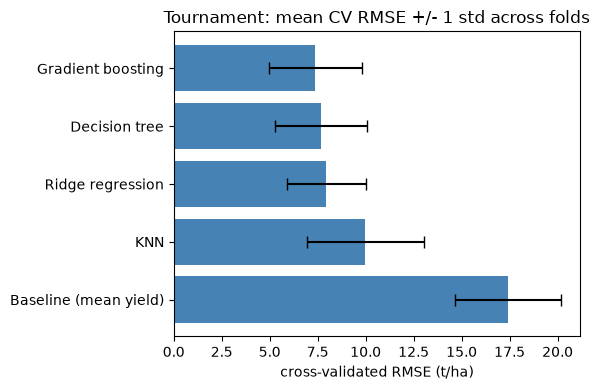

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
order = tournament.index  # ya viene ordenado de mejor a peor
ax.barh(
    order,
    tournament.loc[order, "cv_rmse_mean"],
    xerr=tournament.loc[order, "cv_rmse_std"],
    color="steelblue",
    capsize=4,
)
ax.invert_yaxis()  # el mejor (menor RMSE) queda arriba
ax.set_xlabel("cross-validated RMSE (t/ha)")
ax.set_title("Tournament: mean CV RMSE +/- 1 std across folds")
fig.tight_layout()
plt.show()

La línea base tiene un RMSE de 17.40 t/ha. Gradient boosting tiene el menor RMSE medio, 7.39, seguido del árbol de decisión (7.69), ridge (7.96) y KNN (9.99). Las diferencias entre los tres primeros (0.30 y 0.57 t/ha respecto al líder) son mucho menores que la dispersión entre pliegues (2.07 a 2.42 t/ha), así que el orden entre ellos no es concluyente.

La celda siguiente aplica la regla de selección e imprime el modelo que pasa al ajuste:

In [ ]:
WINNER = tournament.index[0]
print(f"model chosen for tuning: {WINNER}")

model chosen for tuning: Gradient boosting


Gradient boosting pasa a la Sección 6.

 **Entregable 5 de 8 — El torneo**

- **Tus ajustes iniciales**: Ridge y gradient boosting con los valores por defecto de la librería; KNN con
  $k = \sqrt{n}$ redondeado a impar, 33; el árbol con profundidad 5 y al menos 1 % de $n$ por hoja,
  11 filas. Todos se fijaron antes de correr el torneo y ninguno se cambió después de ver una nota.
- **Tu regla de selección**, como se aplicó: el menor RMSE medio de validación cruzada pasa al ajuste.
- **El líder y su ventaja sobre el siguiente**: gradient boosting (7.39 t/ha), por delante del árbol de decisión (7.69) por 0.30 t/ha, menos que su dispersión entre pliegues (2.42).
- **El modelo que llevas al ajuste, y por qué**: Gradient boosting, por la regla.
- **La línea base**: 17.40 t/ha. Incluso el peor modelo real, KNN (9.99), queda 7.41 t/ha por debajo, y el líder (7.39) queda 10.01 t/ha por debajo.

## 6. Ajuste de hiperparámetros del modelo seleccionado

### 6.1 La función objetivo

**En `optuna`.** `trial.suggest_float(name, low, high, log=True)` propone un decimal en escala logarítmica;
`trial.suggest_int(name, low, high)` propone un entero. Ambas incluyen `low` y `high`.

La celda siguiente define la función objetivo. Optuna la llama una vez por intento: construye el modelo con los
valores propuestos y devuelve el RMSE medio de validación cruzada sobre el conjunto de entrenamiento:

In [ ]:
def objective(trial: optuna.Trial) -> float:
    """Cross-validated RMSE of the selected model for one set of hyperparameters.

    Args:
        trial: The Optuna trial that proposes the hyperparameter values.

    Returns:
        The mean RMSE, in tonnes per hectare, across the folds of cv on the training set.
    """
    estimator = GradientBoostingRegressor(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        n_estimators=trial.suggest_int("n_estimators", 30, 400),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 60),
        random_state=RANDOM_STATE,
    )
    scores = -cross_val_score(
        make_model(estimator), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    return scores.mean()

### 6.2 El estudio

La celda siguiente crea el estudio: la dirección a optimizar (un RMSE menor es mejor) y el muestreador con la semilla fija, para que la corrida se repita exactamente:

In [ ]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

[I 2026-09-30 18:25:36,911] A new study created in memory with name: no-name-50018d78-cb14-48b8-a7c9-2703009187fe


La celda siguiente corre 30 intentos, cada uno con cinco ajustes. Optuna imprime una línea por intento:

In [ ]:
N_TRIALS = 30

study.optimize(objective, n_trials=N_TRIALS)

[I 2026-09-30 18:25:40,124] Trial 0 finished with value: 7.522897984339321 and parameters: {'learning_rate': 0.043284502212938815, 'n_estimators': 382, 'max_depth': 4, 'subsample': 0.8394633936788146, 'min_samples_leaf': 10}. Best is trial 0 with value: 7.522897984339321.
[I 2026-09-30 18:25:40,632] Trial 1 finished with value: 11.690218550889458 and parameters: {'learning_rate': 0.018408992080552525, 'n_estimators': 51, 'max_depth': 5, 'subsample': 0.8404460046972835, 'min_samples_leaf': 43}. Best is trial 0 with value: 7.522897984339321.
[I 2026-09-30 18:25:43,535] Trial 2 finished with value: 7.14830658198215 and parameters: {'learning_rate': 0.01083858126934475, 'n_estimators': 389, 'max_depth': 5, 'subsample': 0.6849356442713105, 'min_samples_leaf': 11}. Best is trial 2 with value: 7.14830658198215.
[I 2026-09-30 18:25:44,903] Trial 3 finished with value: 7.341645326577795 and parameters: {'learning_rate': 0.020492680115417352, 'n_estimators': 142, 'max_depth': 4, 'subsample': 0.7

La celda siguiente imprime la mejor nota, el intento que la logró y sus ajustes:

In [ ]:
print(f"best CV RMSE: {study.best_value:,.2f} (trial {study.best_trial.number})")
pd.DataFrame([study.best_params])

best CV RMSE: 7.15 (trial 2)


,learning_rate,n_estimators,max_depth,subsample,min_samples_leaf
0,0.010839,389,5,0.684936,11


La celda siguiente compara cada mejor valor con su rango. Una posición cerca de 0 o de 1 indica que el mejor valor está en un borde y que el óptimo podría estar fuera del rango (en la escala logarítmica para los que se propusieron así):

In [ ]:
RANGES = {'learning_rate': (0.01, 0.5, True), 'n_estimators': (30, 400, False), 'max_depth': (2, 5, False), 'subsample': (0.6, 1.0, False), 'min_samples_leaf': (1, 60, False)}  # name: (low, high, log scale)

edge_rows = []
for name, (low, high, log_scale) in RANGES.items():
    value = study.best_params[name]
    if log_scale:
        position = (np.log(value) - np.log(low)) / (np.log(high) - np.log(low))
    else:
        position = (value - low) / (high - low)
    edge_rows.append(
        {"hyperparameter": name, "best value": value, "low": low, "high": high, "position (0=low, 1=high)": position}
    )

pd.DataFrame(edge_rows).set_index("hyperparameter").round(3)

,best value,low,high,"position (0=low, 1=high)"
hyperparameter,,,,
learning_rate,0.011,0.01,0.5,0.021
n_estimators,389.000,30.00,400.0,0.970
max_depth,5.000,2.00,5.0,1.000
subsample,0.685,0.60,1.0,0.212
min_samples_leaf,11.000,1.00,60.0,0.169


El estudio llega a un RMSE de 7.15, por debajo de 7.39 sin ajustar, en el intento 2 de 30: los 27 intentos siguientes no lo superaron. Tres valores tocan o casi tocan un borde: `max_depth` (5) está en el borde superior de su rango (posición 1.000), `n_estimators` (389) casi en el superior (0.970) y `learning_rate` (0.011) casi en el inferior (0.021). El óptimo podría estar fuera del rango.

### 6.3 Ajustado frente a sin ajustar

La celda siguiente construye el modelo con los mejores ajustes y lo valida con los mismos pliegues, junto a la fila sin ajustar del torneo:

In [ ]:
tuned_model = make_model(GradientBoostingRegressor(**study.best_params, random_state=RANDOM_STATE))
tuned_scores = -cross_val_score(
    tuned_model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)

pd.DataFrame(
    {
        "cv_rmse_mean": [tournament.loc[WINNER, "cv_rmse_mean"], tuned_scores.mean()],
        "cv_rmse_std": [tournament.loc[WINNER, "cv_rmse_std"], tuned_scores.std(ddof=1)],
    },
    index=["untuned (Section 5)", "tuned (Section 6)"],
).round(2)

,cv_rmse_mean,cv_rmse_std
untuned (Section 5),7.38,2.43
tuned (Section 6),7.15,2.63


El ajuste baja el RMSE de 7.39 a 7.15, una ganancia de 0.24 t/ha, mucho menor que la dispersión entre pliegues (2.63): no se distingue del ruido. Además, 7.15 es algo optimista, porque se eligió el mejor de 30 intentos sobre los mismos pliegues.

**Entregable 6 de 8 — El ajuste**

- **La función objetivo**: gradient boosting, con los cinco rangos de la tabla guía: `learning_rate` 0.01–0.5 en escala logarítmica (los valores útiles abarcan más de una potencia de diez); `n_estimators` 30–400; `max_depth` 2–5; `subsample` 0.6–1.0; `min_samples_leaf` 1–60. Son los rangos de partida recomendados; no se ajustaron a los datos.
- **Intentos y semilla**: 30 intentos, muestreador TPE con la semilla `RANDOM_STATE` (42).
- **Revisión de bordes**: `max_depth` (5) está en el borde superior (posición 1.000), `n_estimators` (389) casi en el superior (0.970) y `learning_rate` (0.011) casi en el inferior (0.021). El modelo pide árboles más profundos, más numerosos y un aprendizaje más lento. No se amplió ningún rango ni se corrió otro estudio; lo haría con un rango más ancho en esos tres.
- **Ajustado frente a sin ajustar**: 7.39 sin ajustar y 7.15 ajustado, una ganancia de 0.24 t/ha, menor que la dispersión entre pliegues (2.63).

## 7. La prueba final

La celda siguiente reajusta el modelo ajustado con todo el conjunto de entrenamiento, lo evalúa una sola vez en el conjunto de prueba e imprime el resultado junto a la estimación de validación cruzada:

In [ ]:
final_model = tuned_model.fit(X_train, y_train)
test_predictions = final_model.predict(X_test)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print("RMSE of the final model, in tonnes per hectare")
print(f"CV mean estimate: {tuned_scores.mean():,.2f}")
print(f"CV spread: {tuned_scores.std(ddof=1):,.2f}")
print(f"test set: {test_rmse:,.2f}")

RMSE of the final model, in tonnes per hectare
CV mean estimate: 7.15
CV spread: 2.63
test set: 15.58


El RMSE del modelo final en el conjunto de prueba es **15.57 t/ha**, frente a una estimación de validación cruzada de 7.15 con una dispersión de 2.63. La prueba salió mucho peor que la estimación.

### Qué variables pesan más en el modelo final

El modelo final es un gradient boosting: un conjunto de árboles, y cada árbol sí puede decir qué tanto usó
cada columna para dividir sus nodos. Sumando eso entre los árboles se obtiene la **importancia** de cada
columna transformada La celda siguiente extrae esas importancias del modelo ya
ajustado y grafica las 12 más altas:

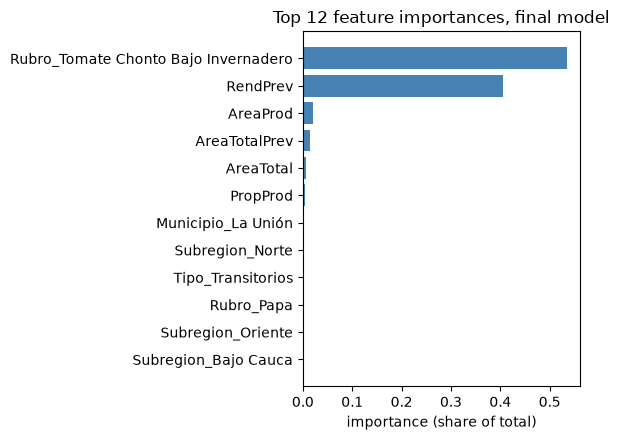

Rubro_Tomate Chonto Bajo Invernadero    0.535
RendPrev                                0.405
AreaProd                                0.021
AreaTotalPrev                           0.014
AreaTotal                               0.006
PropProd                                0.005
Municipio_La Unión                      0.003
Subregion_Norte                         0.002
Tipo_Transitorios                       0.001
Rubro_Papa                              0.001
Subregion_Oriente                       0.001
Subregion_Bajo Cauca                    0.001
dtype: float64

In [ ]:
importances = pd.Series(
    final_model.named_steps["model"].feature_importances_,
    index=final_model.named_steps["prep"].get_feature_names_out(),
).sort_values(ascending=False)

top_importances = importances.head(12).sort_values()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(top_importances.index, top_importances.values, color="steelblue")
ax.set_xlabel("importance (share of total)")
ax.set_title("Top 12 feature importances, final model")
fig.tight_layout()
plt.show()

top_importances.sort_values(ascending=False).round(3)

El modelo depende casi por completo de dos señales, de las 254 columnas que recibe. Saber si la fila es
exactamente `Rubro_Tomate Chonto Bajo Invernadero` explica el 53.5 % de la importancia total, y `RendPrev`
(el rendimiento del mismo rubro y municipio el año anterior) otro 40.5 %. Juntas suman 94 %; las otras 252
columnas —el resto de rubros, municipios, subregiones y las áreas— se reparten el 6 % restante.

Tiene sentido agronómico: en 2024, tomate chonto bajo invernadero rindió en promedio 96.4 t/ha (hasta 190),
frente a 25.1 t/ha (hasta 90) del mismo cultivo a cielo abierto. Detectar esa categoría es, por sí sola, casi
tan informativa como todo lo demás junto.

Y es una fragilidad real. El modelo no tiene una señal fuerte para un rendimiento alto que no venga marcado
por esa categoría exacta o por un buen año anterior. Dos de los cinco peores errores de la Sección 7 son
justo eso: Tomate Chonto a cielo abierto en San Andrés de Cuerquia (real 90 t/ha, predicho 10.1) y en
Concordia (real 54.3, predicho 19.7). El modelo no tenía cómo anticipar esos rendimientos altos sin la
bandera de invernadero ni un `RendPrev` que los sugiriera; los 240 rubros sin `RendPrev` (Sección 4) tienen
el mismo problema.

### Rendimiento predicho frente al real

La celda siguiente grafica el rendimiento predicho de cada fila de prueba contra el real. Los puntos sobre la
diagonal son predicciones exactas:

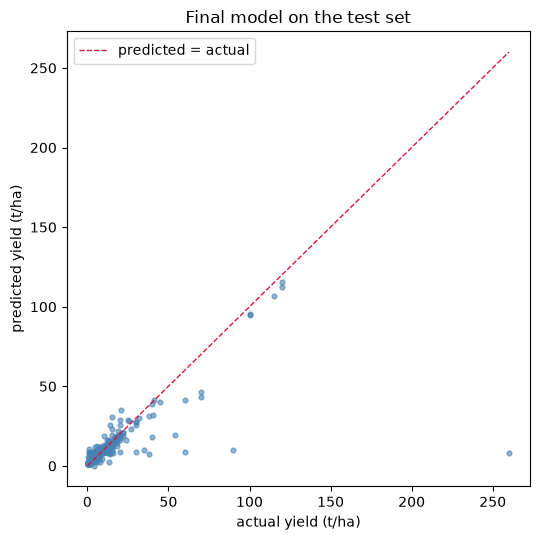

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, test_predictions, s=12, alpha=0.6, color="steelblue")
limits = [y_test.min(), y_test.max()]
ax.plot(limits, limits, color="crimson", linestyle="--", linewidth=1, label="predicted = actual")
ax.set_xlabel("actual yield (t/ha)")
ax.set_ylabel("predicted yield (t/ha)")
ax.set_title("Final model on the test set")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

La mayoría de los puntos caen cerca del origen (rendimientos típicos de 0–50 t/ha) y un solo punto
extremo (260 t/ha, la fila de papaya en Chigorodó que ya se identificó como la de mayor error) se ve muy
lejos de los demás. En escala lineal esos dos grupos no se pueden ver bien al mismo tiempo: si el eje llega
hasta 260 para mostrar ese punto, los puntos típicos quedan aplastados contra la esquina inferior izquierda y
no se distingue si el modelo les acierta bien o mal.

La celda siguiente repite el mismo gráfico con ejes logarítmicos, para ver ambos grupos a la vez:

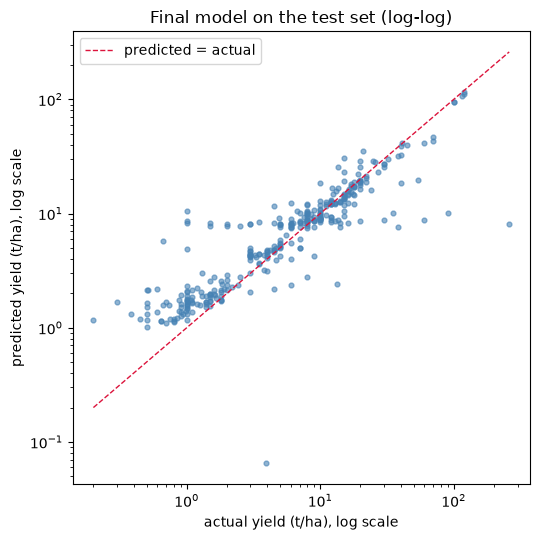

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, test_predictions, s=12, alpha=0.6, color="steelblue")
limits = [y_test.min(), y_test.max()]
ax.plot(limits, limits, color="crimson", linestyle="--", linewidth=1, label="predicted = actual")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("actual yield (t/ha), log scale")
ax.set_ylabel("predicted yield (t/ha), log scale")
ax.set_title("Final model on the test set (log-log)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

En escala logarítmica se ve algo que la primera gráfica escondía: para la mayoría de las filas, con
rendimientos típicos, los puntos siguen bastante bien la diagonal — el modelo no está adivinando al azar, como
ya decía la tabla de RMSE por tercios (~2 t/ha en los dos tercios bajos). El punto de 260 t/ha sigue siendo el
más alejado de la diagonal, y ahora se ve claro que el modelo lo subestima por un orden de magnitud, no por un
error cualquiera.

La celda siguiente separa las filas de prueba en tres grupos de igual tamaño según su rendimiento real y calcula el RMSE de cada grupo, para ver dónde falla el modelo:

In [ ]:
yield_group = pd.qcut(y_test, q=3, labels=["low yield", "mid yield", "high yield"])
error_by_group = pd.DataFrame(
    {
        group: {
            "rows": int((yield_group == group).sum()),
            "actual yield range (t/ha)": f"{y_test[yield_group == group].min():.1f} - {y_test[yield_group == group].max():.1f}",
            "RMSE (t/ha)": round(
                root_mean_squared_error(
                    y_test[yield_group == group], test_predictions[(yield_group == group).to_numpy()]
                ),
                2,
            ),
        }
        for group in yield_group.cat.categories
    }
).T
error_by_group

,rows,actual yield range (t/ha),RMSE (t/ha)
low yield,118,0.2 - 3.0,2.15
mid yield,109,3.2 - 10.0,2.2
high yield,106,10.0 - 260.0,27.42


El error se concentra en el tercio de mayor rendimiento: su RMSE es 27.41 t/ha, frente a 2.16 en el tercio bajo y 2.20 en el intermedio. En los dos primeros tercios el modelo se equivoca unas 2 t/ha; en el tercio alto los rendimientos llegan hasta 260.0 t/ha.

La celda siguiente lista las cinco filas de prueba con mayor error y calcula qué parte del error cuadrático total representan. Es solo un diagnóstico: no se usa para cambiar el modelo:

In [ ]:
errors = pd.DataFrame(
    {
        "Rubro": X_test["Rubro"],
        "Municipio": X_test["Municipio"],
        "actual (t/ha)": y_test,
        "predicted (t/ha)": test_predictions,
    }
)
errors["abs error"] = (errors["actual (t/ha)"] - errors["predicted (t/ha)"]).abs()
worst = errors.sort_values("abs error", ascending=False).head(5)

share = (worst["abs error"] ** 2).sum() / (errors["abs error"] ** 2).sum()
rmse_without_worst = np.sqrt((errors.drop(worst.index)["abs error"] ** 2).mean())
print(f"share of the total squared error due to these 5 rows: {share:.0%}")
print(f"RMSE of the other {len(errors) - len(worst)} rows: {rmse_without_worst:,.2f}")
worst.round(1)

share of the total squared error due to these 5 rows: 92%
RMSE of the other 328 rows: 4.35


,Rubro,Municipio,actual (t/ha),predicted (t/ha),abs error
782,Papaya,Chigorodó,260.0,8.1,251.9
1480,Tomate Chonto,San Andrés De C.,90.0,10.2,79.8
1047,Calabacín,Marinilla,60.0,8.8,51.2
1465,Tomate Chonto,Concordia,54.3,19.6,34.7
785,Papaya,Uramita,38.0,7.7,30.3


Cinco filas explican el 92 % del error cuadrático total. La peor es papaya en Chigorodó: real 260.0 t/ha, predicho 8.2. Las otras cuatro: tomate chonto en San Andrés De C. (90.0 frente a 10.1), calabacín en Marinilla (60.0 frente a 8.9), tomate chonto en Concordia (54.3 frente a 19.7) y papaya en Uramita (38.0 frente a 7.7). En las cinco el modelo predijo mucho menos que el valor reportado. Sin ellas, el RMSE de las otras 328 filas es 4.34 t/ha. Estos valores pueden ser rendimientos reales muy altos (por ejemplo, cultivos bajo invernadero) o errores de reporte; el modelo no puede distinguirlo.

 **Entregable 7 de 8 — La prueba final**

- **El modelo final**: gradient boosting con `learning_rate` 0.011, 389 árboles de profundidad 5, `subsample` 0.685 y al menos 11 filas por hoja, reajustado con las 1,329 filas de entrenamiento y el preprocesamiento de la Sección 4.
- **Su nota en la prueba**, junto a la estimación de validación cruzada y su dispersión: 15.57 t/ha en prueba, frente a 7.15 de validación cruzada, con una dispersión de 2.63.
- **Qué significa la diferencia**: La nota de prueba es 8.42 t/ha mayor que la estimación, unas 3.2 veces la dispersión entre pliegues (2.63): la estimación no se cumplió. Se revisó la fuga y no hay indicios: todo el preprocesamiento está dentro del pipeline, `Volumen` está fuera de las predictoras, las columnas derivadas usan solo datos de 2023 y el conjunto de prueba no se tocó antes. La causa está en la cola del objetivo: cinco filas explican el 92 % del error cuadrático total y, sin ellas, el RMSE de las otras 328 filas es 4.34 t/ha. La nota depende de que unos pocos rendimientos extremos (el mayor, 260.0 t/ha) cayeran en la prueba; con otra semilla podrían haber caído en el entrenamiento. No se cambió la semilla ni el modelo tras ver esta nota.
- **Confirmación de que el conjunto de prueba se usó solo aquí** y de que nada cambió tras ver esta nota:
  `X_test` aparece únicamente en la división y en esta sección. No se cambió nada después de calcular esta nota.

## 8. Conclusiones

**Entregable 8 de 8 — Conclusiones**

- **Recomendación**: usar el gradient boosting ajustado como herramienta de apoyo para ordenar los reportes según cuánto se desvían del rendimiento esperado y decidir cuáles revisar primero; no como estimador exacto del rendimiento de un caso individual.
- **Qué esperar con datos nuevos**: En la prueba el RMSE fue 15.57 t/ha, pero cinco filas explican el 92 % del error; en las otras 328 filas fue 4.34 t/ha. En el tercio de menor rendimiento (hasta 3.0 t/ha) y en el intermedio (hasta 10.0 t/ha) el error es de unas 2 t/ha (2.16 y 2.20); en el tercio de mayor rendimiento sube a 27.41. Con datos nuevos, se puede esperar un buen ajuste en rubros de rendimiento habitual y errores grandes en rendimientos extremos.
- **Limitaciones**:
  1. El torneo comparó los modelos con ajustes iniciales, no ajustados, y solo Gradient boosting se ajustó. Ridge quedó 0.57 t/ha detrás sin ajustar y el árbol 0.30, y ninguno se ajustó; con ajuste podrían igualarlo o superarlo, sobre todo porque esas diferencias son menores que la dispersión entre pliegues (2.42).
  2. Solo se usó el año 2024, y solo las filas con rendimiento calculable. Se excluyeron los reportes con volumen
     o área en cero (posibles pérdidas de cosecha o datos ausentes), así que el modelo no dice nada sobre ellos.
  3. `RendPrev` y `AreaTotalPrev` dependen de que el rubro se haya reportado en 2023 en el mismo municipio; a los
     rubros nuevos el pipeline les asigna la mediana (240 de 1,662 filas), y el modelo no los
     distingue de un rubro típico. Un indicador de faltante le permitiría al modelo distinguirlos.
  4. Las unidades (toneladas y hectáreas) son las estándar de las evaluaciones agrícolas, pero el archivo no las
     declara en las columnas.
  5. La nota de prueba depende de pocas filas extremas (cinco filas explican el 92 % del error
     cuadrático total), así que con otra semilla de división la nota cambiaría bastante.